# Model 3 - Full Dynamic

This notebook implements the strongest predictive specification among the three rebuilt GDP models. It combines lag GDP, socio-economic indicators, trainable global event dummies, region effects, and a linear year trend.

**Formula**

`target_log_gdp_next_year ~ log_gdp_per_capita + log_population_total + life_expectancy_years + inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean + asian_financial_crisis_9798 + global_financial_crisis_0809 + C(wb_region) + year_trend`


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [4]:
if "__file__" in globals():
    BASE_DIR = Path(__file__).resolve().parents[1]
else:
    BASE_DIR = Path("/Users/tonytony/Final Project")

DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

TRAIN_END_YEAR = 2017
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

MODEL_NAME = "Model 3 - Full Dynamic"
FORMULA = "target_log_gdp_next_year ~ log_gdp_per_capita + log_population_total + life_expectancy_years + inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean + asian_financial_crisis_9798 + global_financial_crisis_0809 + C(wb_region) + year_trend"
OUTPUT_PREFIX = "gdp_model_3_full_dynamic"

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)


Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned


In [5]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted) ** 2))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    sst = np.sum((actual - actual.mean()) ** 2)
    sse = np.sum((actual - predicted) ** 2)
    r2 = 1 - (sse / sst) if sst > 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def build_prediction_frame(model, df):
    pred_df = df.copy()
    pred_df["predicted_log_gdp_next_year"] = model.predict(pred_df)
    pred_df["actual_log_gdp_next_year"] = pred_df["target_log_gdp_next_year"]

    pred_df["predicted_gdp_next_year"] = np.exp(pred_df["predicted_log_gdp_next_year"])
    pred_df["actual_gdp_next_year"] = np.exp(pred_df["actual_log_gdp_next_year"])

    pred_df["feature_year"] = pred_df["year"].astype(int)
    pred_df["target_year"] = pred_df["feature_year"] + 1
    pred_df["absolute_error_usd"] = np.abs(
        pred_df["actual_gdp_next_year"] - pred_df["predicted_gdp_next_year"]
    )
    pred_df["absolute_percentage_error_pct"] = (
        pred_df["absolute_error_usd"] / pred_df["actual_gdp_next_year"]
    ) * 100
    pred_df["signed_percentage_error_pct"] = (
        (pred_df["predicted_gdp_next_year"] - pred_df["actual_gdp_next_year"])
        / pred_df["actual_gdp_next_year"]
    ) * 100
    return pred_df


def build_region_metrics(df):
    rows = []
    for region_name, region_df in df.groupby("wb_region"):
        metrics = regression_metrics(
            actual=region_df["actual_gdp_next_year"],
            predicted=region_df["predicted_gdp_next_year"],
        )
        rows.append(
            {
                "wb_region": region_name,
                "n_obs": len(region_df),
                **metrics,
            }
        )
    return pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)


def build_yearly_summary(df):
    rows = []
    for target_year, year_df in df.groupby("target_year"):
        rows.append(
            {
                "target_year": int(target_year),
                "n_obs": len(year_df),
                "actual_mean_gdp": year_df["actual_gdp_next_year"].mean(),
                "predicted_mean_gdp": year_df["predicted_gdp_next_year"].mean(),
                "pred_to_actual_ratio": (
                    year_df["predicted_gdp_next_year"].mean()
                    / year_df["actual_gdp_next_year"].mean()
                ),
                "mean_absolute_percentage_error_pct": year_df[
                    "absolute_percentage_error_pct"
                ].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values("target_year").reset_index(drop=True)


def show_or_close_plot():
    if "ipykernel" in sys.modules:
        plt.show()
    else:
        plt.close()


In [6]:
model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]

panel_df = pd.read_csv(DATA_PATH, usecols=model_cols)
model_df = panel_df.dropna().copy()

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
]
for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)
model_df["country_name"] = model_df["country_name"].astype(str)
model_df["country_code"] = model_df["country_code"].astype(str)
model_df["wb_region"] = model_df["wb_region"].astype(str)
model_df["year_trend"] = model_df["year"] - model_df["year"].min()

print("Model sample shape:", model_df.shape)
print("Countries:", model_df["country_code"].nunique())
print("Regions:", model_df["wb_region"].nunique())
print("Feature-year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))
print(
    "Target-year range:",
    int((model_df["year"] + 1).min()),
    "-",
    int((model_df["year"] + 1).max()),
)

model_df.head()


Model sample shape: (4722, 16)
Countries: 177
Regions: 7
Feature-year range: 1991 - 2022
Target-year range: 1992 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,asian_financial_crisis_9798,global_financial_crisis_0809,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,year_trend
43,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2005,254.1842,58.2470,"24,404,567.0000",5.5381,17.0103,5.6139,0,0,12.6863,7.8780,1.2241,14
44,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2006,274.2186,58.5530,"25,424,094.0000",5.6139,17.0512,5.9302,0,0,6.7846,7.8970,2.1071,15
45,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2007,376.2232,58.9560,"25,909,852.0000",5.9302,17.0701,5.9447,0,0,8.6806,7.8410,1.9000,16
46,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2008,381.7332,59.7080,"26,482,622.0000",5.9447,17.0920,6.1138,0,1,26.4187,7.8790,1.8400,17
47,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2009,452.0537,60.2480,"27,466,101.0000",6.1138,17.1285,6.3290,0,1,-2.8285,7.8080,3.5500,18


In [7]:
train_df = model_df[model_df["year"] <= TRAIN_END_YEAR].copy()
test_df = model_df[
    (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)
].copy()

print("Train rows:", train_df.shape[0])
print("Test rows:", test_df.shape[0])
print("Train countries:", train_df["country_code"].nunique())
print("Test countries:", test_df["country_code"].nunique())
print(
    "Train feature years:",
    int(train_df["year"].min()),
    "-",
    int(train_df["year"].max()),
)
print(
    "Test feature years:",
    int(test_df["year"].min()),
    "-",
    int(test_df["year"].max()),
)
print(
    "Test target years:",
    int((test_df["year"] + 1).min()),
    "-",
    int((test_df["year"] + 1).max()),
)


Train rows: 3909
Test rows: 813
Train countries: 176
Test countries: 167
Train feature years: 1991 - 2017
Test feature years: 2018 - 2022
Test target years: 2019 - 2023


In [8]:
fitted_model = smf.ols(formula=FORMULA, data=train_df).fit(cov_type="HC3")

print(MODEL_NAME)
print("Formula:", FORMULA)
print("Train R-squared:", round(fitted_model.rsquared, 4))
print(fitted_model.summary())


Model 3 - Full Dynamic
Formula: target_log_gdp_next_year ~ log_gdp_per_capita + log_population_total + life_expectancy_years + inflation_pct_clean + unemployment_pct_clean + internet_users_pct_clean + asian_financial_crisis_9798 + global_financial_crisis_0809 + C(wb_region) + year_trend
Train R-squared: 0.9933
                               OLS Regression Results                               
Dep. Variable:     target_log_gdp_next_year   R-squared:                       0.993
Model:                                  OLS   Adj. R-squared:                  0.993
Method:                       Least Squares   F-statistic:                 4.842e+04
Date:                      Fri, 17 Jul 2026   Prob (F-statistic):               0.00
Time:                              17:08:53   Log-Likelihood:                 2509.5
No. Observations:                      3909   AIC:                            -4987.
Df Residuals:                          3893   BIC:                            -4887.
Df Model

In [9]:
coef_ci = fitted_model.conf_int()
coef_table = pd.DataFrame(
    {
        "term": fitted_model.params.index,
        "coefficient": fitted_model.params.values,
        "std_error": fitted_model.bse.values,
        "t_value": fitted_model.tvalues.values,
        "p_value": fitted_model.pvalues.values,
        "ci_lower": coef_ci[0].values,
        "ci_upper": coef_ci[1].values,
    }
).round(6)

coef_table


,term,coefficient,std_error,t_value,p_value,ci_lower,ci_upper
0,Intercept,0.1663,0.0398,4.1758,0.0000,0.0882,0.2443
1,C(wb_region)[T.Europe & Central Asia],0.0101,0.0068,1.4955,0.1348,-0.0031,0.0233
2,C(wb_region)[T.Latin America & Caribbean ],-0.0087,0.0067,-1.2995,0.1938,-0.0218,0.0044
3,"C(wb_region)[T.Middle East, North Africa, Afgh...",-0.0100,0.0079,-1.2535,0.2100,-0.0255,0.0056
4,C(wb_region)[T.North America],0.0133,0.0112,1.1892,0.2344,-0.0086,0.0352
5,C(wb_region)[T.South Asia],-0.0002,0.0087,-0.0286,0.9772,-0.0173,0.0168
6,C(wb_region)[T.Sub-Saharan Africa ],-0.0235,0.0092,-2.5363,0.0112,-0.0416,-0.0053
7,log_gdp_per_capita,0.9841,0.0034,291.0201,0.0000,0.9775,0.9908
8,log_population_total,-0.0024,0.0011,-2.1317,0.0330,-0.0047,-0.0002
9,life_expectancy_years,0.0012,0.0007,1.9111,0.0560,-0.0000,0.0025


In [10]:
train_predictions_df = build_prediction_frame(fitted_model, train_df)
test_predictions_df = build_prediction_frame(fitted_model, test_df)

metrics_df = pd.DataFrame(
    [
        {
            "split": "train",
            "scale": "level_gdp_usd",
            "model": MODEL_NAME,
            "n_obs": len(train_predictions_df),
            **regression_metrics(
                actual=train_predictions_df["actual_gdp_next_year"],
                predicted=train_predictions_df["predicted_gdp_next_year"],
            ),
        },
        {
            "split": "train",
            "scale": "log_gdp",
            "model": MODEL_NAME,
            "n_obs": len(train_predictions_df),
            **regression_metrics(
                actual=train_predictions_df["actual_log_gdp_next_year"],
                predicted=train_predictions_df["predicted_log_gdp_next_year"],
            ),
        },
        {
            "split": "test",
            "scale": "level_gdp_usd",
            "model": MODEL_NAME,
            "n_obs": len(test_predictions_df),
            **regression_metrics(
                actual=test_predictions_df["actual_gdp_next_year"],
                predicted=test_predictions_df["predicted_gdp_next_year"],
            ),
        },
        {
            "split": "test",
            "scale": "log_gdp",
            "model": MODEL_NAME,
            "n_obs": len(test_predictions_df),
            **regression_metrics(
                actual=test_predictions_df["actual_log_gdp_next_year"],
                predicted=test_predictions_df["predicted_log_gdp_next_year"],
            ),
        },
    ]
).round(4)

metrics_df


,split,scale,model,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,train,level_gdp_usd,Model 3 - Full Dynamic,3909,913.8368,"2,110.8172",8.7943,0.9850
1,train,log_gdp,Model 3 - Full Dynamic,3909,0.0864,0.1273,1.0952,0.9933
2,test,level_gdp_usd,Model 3 - Full Dynamic,813,"1,468.1942","3,472.9950",8.8964,0.9766
3,test,log_gdp,Model 3 - Full Dynamic,813,0.0878,0.1220,1.0074,0.9926


In [11]:
region_metrics_df = build_region_metrics(test_predictions_df).round(4)
region_metrics_df


,wb_region,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,Sub-Saharan Africa,204,219.8328,418.5862,8.0586,0.9670
1,South Asia,30,456.2677,"1,050.4420",9.0731,0.8937
2,Latin America & Caribbean,127,"1,072.7444","1,704.6466",9.9997,0.9404
3,Europe & Central Asia,229,"2,197.3619","3,891.2235",7.5928,0.9814
4,"Middle East, North Africa, Afghanistan & Pakistan",102,"2,180.5993","4,101.4970",12.6020,0.9588
5,North America,10,"3,908.4328","4,519.9519",6.4927,0.8546
6,East Asia & Pacific,111,"2,109.6224","5,988.4792",8.6273,0.9338


In [12]:
bias_summary_df = pd.DataFrame(
    [
        {
            "model": MODEL_NAME,
            "n_obs": len(test_predictions_df),
            "actual_mean_gdp": test_predictions_df["actual_gdp_next_year"].mean(),
            "predicted_mean_gdp": test_predictions_df["predicted_gdp_next_year"].mean(),
            "actual_median_gdp": test_predictions_df["actual_gdp_next_year"].median(),
            "predicted_median_gdp": test_predictions_df["predicted_gdp_next_year"].median(),
            "mean_absolute_percentage_error_pct": test_predictions_df[
                "absolute_percentage_error_pct"
            ].mean(),
            "mean_signed_percentage_error_pct": test_predictions_df[
                "signed_percentage_error_pct"
            ].mean(),
            "median_signed_percentage_error_pct": test_predictions_df[
                "signed_percentage_error_pct"
            ].median(),
            "pred_to_actual_mean_ratio": (
                test_predictions_df["predicted_gdp_next_year"].mean()
                / test_predictions_df["actual_gdp_next_year"].mean()
            ),
        }
    ]
).round(4)

bias_summary_df


,model,n_obs,actual_mean_gdp,predicted_mean_gdp,actual_median_gdp,predicted_median_gdp,mean_absolute_percentage_error_pct,mean_signed_percentage_error_pct,median_signed_percentage_error_pct,pred_to_actual_mean_ratio
0,Model 3 - Full Dynamic,813,"16,845.5917","16,680.9274","6,542.8558","6,492.7372",8.8964,1.0965,0.7402,0.9902


In [13]:
yearly_summary_df = build_yearly_summary(test_predictions_df).round(4)
yearly_summary_df


,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,2019,166,"15,698.9605","16,288.2888",1.0375,5.3232
1,2020,166,"14,549.3612","16,049.5349",1.1031,12.8261
2,2021,162,"17,155.0981","15,069.2342",0.8784,10.4037
3,2022,160,"18,048.6179","17,634.9957",0.9771,8.2109
4,2023,159,"18,914.0876","18,432.0753",0.9745,7.6784


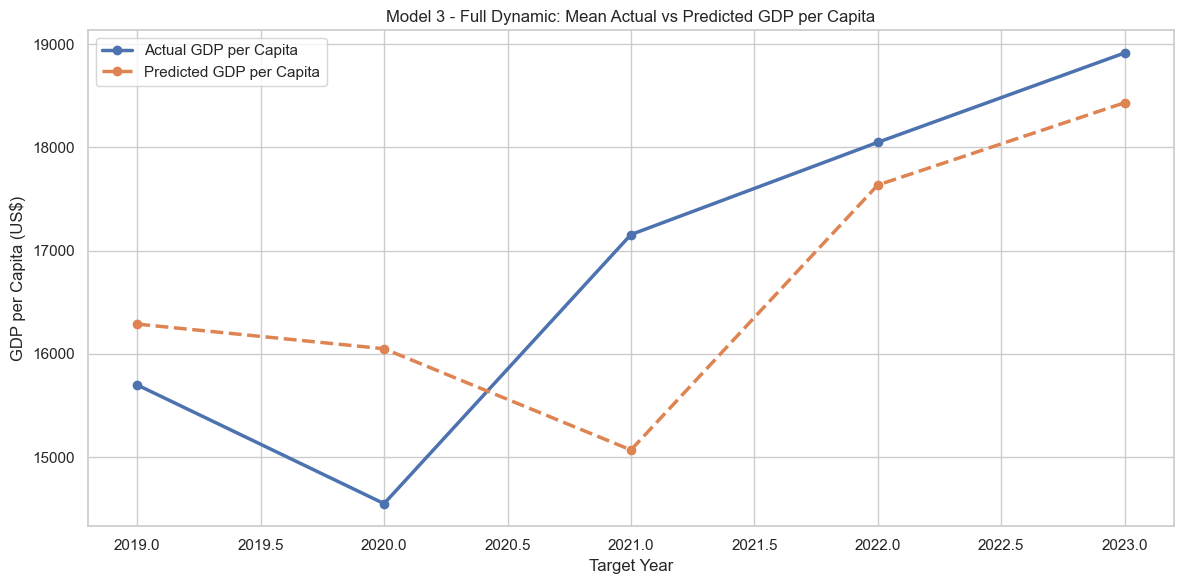

In [14]:
year_plot_df = (
    test_predictions_df.groupby("target_year", as_index=False)[
        ["actual_gdp_next_year", "predicted_gdp_next_year"]
    ]
    .mean()
    .sort_values("target_year")
)

plt.figure(figsize=(12, 6))
plt.plot(
    year_plot_df["target_year"],
    year_plot_df["actual_gdp_next_year"],
    marker="o",
    linewidth=2.5,
    label="Actual GDP per Capita",
)
plt.plot(
    year_plot_df["target_year"],
    year_plot_df["predicted_gdp_next_year"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Predicted GDP per Capita",
)
plt.title(f"{MODEL_NAME}: Mean Actual vs Predicted GDP per Capita")
plt.xlabel("Target Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
show_or_close_plot()


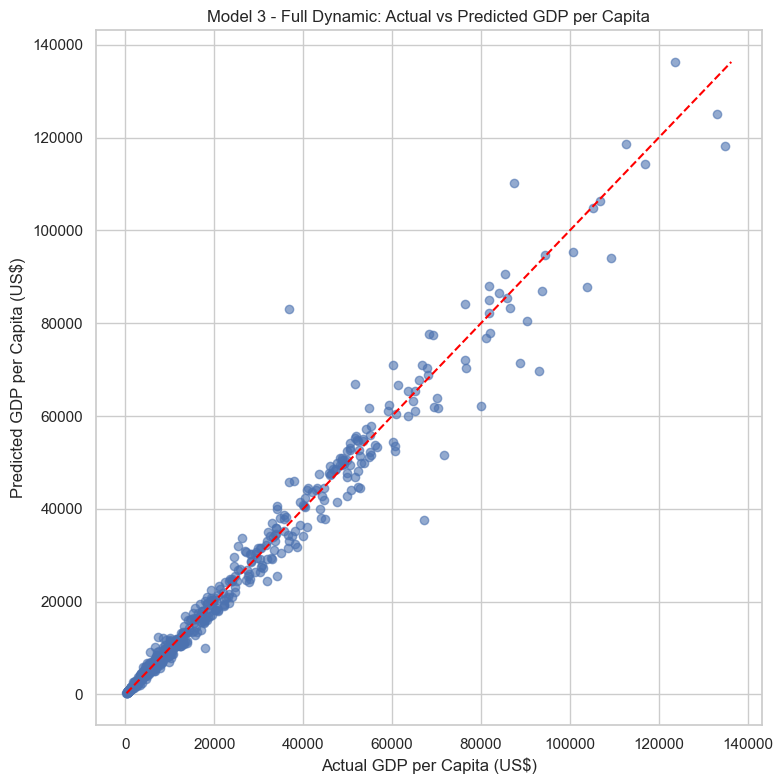

In [15]:
plt.figure(figsize=(8, 8))
plt.scatter(
    test_predictions_df["actual_gdp_next_year"],
    test_predictions_df["predicted_gdp_next_year"],
    alpha=0.6,
)

diag_min = min(
    test_predictions_df["actual_gdp_next_year"].min(),
    test_predictions_df["predicted_gdp_next_year"].min(),
)
diag_max = max(
    test_predictions_df["actual_gdp_next_year"].max(),
    test_predictions_df["predicted_gdp_next_year"].max(),
)
plt.plot([diag_min, diag_max], [diag_min, diag_max], color="red", linestyle="--")
plt.title(f"{MODEL_NAME}: Actual vs Predicted GDP per Capita")
plt.xlabel("Actual GDP per Capita (US$)")
plt.ylabel("Predicted GDP per Capita (US$)")
plt.tight_layout()
show_or_close_plot()


In [16]:
output_files = {
    "metrics": OUTPUT_DIR / f"{OUTPUT_PREFIX}_metrics.csv",
    "coefficients": OUTPUT_DIR / f"{OUTPUT_PREFIX}_coefficients.csv",
    "test_predictions": OUTPUT_DIR / f"{OUTPUT_PREFIX}_test_predictions.csv",
    "region_metrics": OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_metrics.csv",
    "yearly_summary": OUTPUT_DIR / f"{OUTPUT_PREFIX}_yearly_summary.csv",
    "bias_summary": OUTPUT_DIR / f"{OUTPUT_PREFIX}_bias_summary.csv",
}

metrics_df.to_csv(output_files["metrics"], index=False)
coef_table.to_csv(output_files["coefficients"], index=False)
test_predictions_df.to_csv(output_files["test_predictions"], index=False)
region_metrics_df.to_csv(output_files["region_metrics"], index=False)
yearly_summary_df.to_csv(output_files["yearly_summary"], index=False)
bias_summary_df.to_csv(output_files["bias_summary"], index=False)

for label, path in output_files.items():
    print(f"{label}: {path}")


metrics: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_metrics.csv
coefficients: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_coefficients.csv
test_predictions: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_test_predictions.csv
region_metrics: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_region_metrics.csv
yearly_summary: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_yearly_summary.csv
bias_summary: /Users/tonytony/Final Project/Data/Cleaned/gdp_model_3_full_dynamic_bias_summary.csv
